In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [2]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [4]:
def init_params():
    w1 = np.random.randn(10, 784) * 0.01 # Initialize weights with a smaller scale
    b1 = np.zeros((10, 1)) # Initialize biases to zero
    w2 = np.random.randn(10, 10) * 0.01 # Similarly scale w2
    b2 = np.zeros((10, 1)) # Initialize biases to zero
    return [w1, b1, w2, b2]

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
# Compute softmax values for each sets of scores in x
    exp = np.exp(Z - np.max(Z))
    return exp / exp.sum(axis=0)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    # index for the rows
    one_hot_Y[np.arange(Y.size), Y] = 1
    # each column is a vector 'one-hot'
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[8 6 6 ... 4 7 4] [2 9 4 ... 3 0 9]
0.083
Iteration:  10
[8 6 6 ... 4 0 7] [2 9 4 ... 3 0 9]
0.20873170731707316
Iteration:  20
[4 6 6 ... 4 0 7] [2 9 4 ... 3 0 9]
0.26607317073170733
Iteration:  30
[4 6 6 ... 4 0 7] [2 9 4 ... 3 0 9]
0.24636585365853658
Iteration:  40
[4 6 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.22409756097560976
Iteration:  50
[7 7 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.2095121951219512
Iteration:  60
[7 7 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.21285365853658536
Iteration:  70
[7 7 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.23656097560975609
Iteration:  80
[4 7 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.29334146341463413
Iteration:  90
[4 7 7 ... 4 0 7] [2 9 4 ... 3 0 9]
0.4163414634146341
Iteration:  100
[4 7 7 ... 8 0 7] [2 9 4 ... 3 0 9]
0.5517073170731708
Iteration:  110
[4 8 9 ... 8 0 7] [2 9 4 ... 3 0 9]
0.6363170731707317
Iteration:  120
[4 8 4 ... 8 0 7] [2 9 4 ... 3 0 9]
0.6739756097560976
Iteration:  130
[4 8 4 ... 8 0 7] [2 9 4 ... 3 0 9]
0.7002926829268292
Iteration:  140
[4 8 4 

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [0]
Label:  0


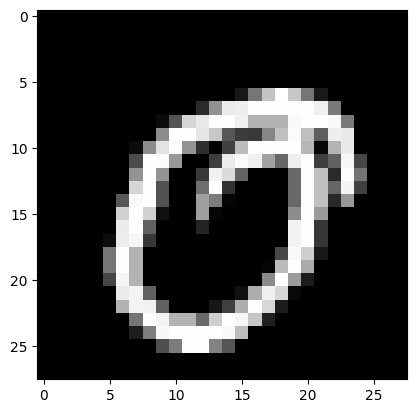

Prediction:  [9]
Label:  9


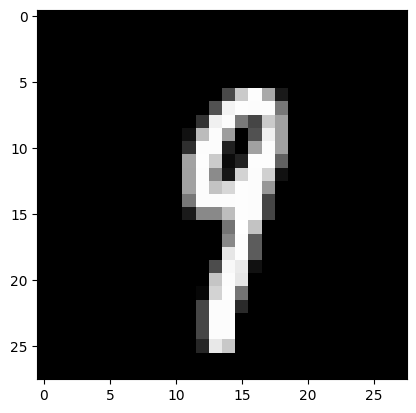

Prediction:  [9]
Label:  4


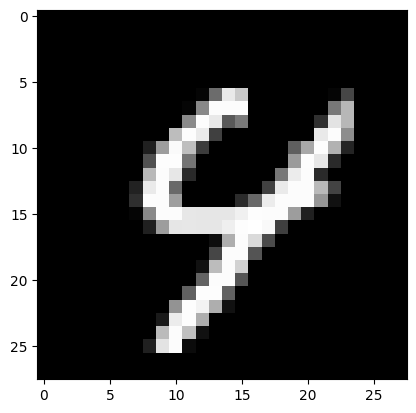

Prediction:  [5]
Label:  5


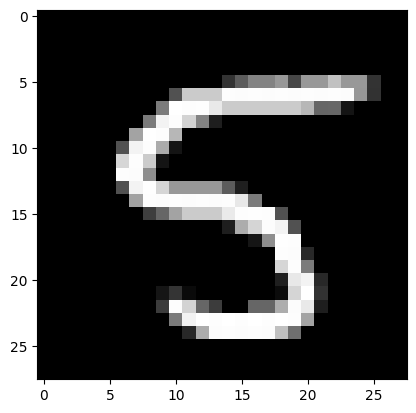

In [8]:
test_prediction(18, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [9]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[7 1 2 5 7 6 9 9 7 9 5 3 8 4 4 4 7 3 5 0 8 7 0 3 6 4 1 9 3 2 4 7 6 4 1 3 8
 3 8 9 4 7 2 9 7 7 7 7 7 2 1 9 6 7 1 5 6 5 0 9 3 1 7 2 2 0 4 0 9 0 0 4 3 5
 4 1 5 9 6 1 5 7 1 4 5 1 4 5 3 9 4 7 6 2 1 0 5 7 4 8 3 9 0 4 3 5 8 9 3 9 1
 1 2 3 1 1 3 1 7 1 5 7 0 8 2 9 6 7 8 6 1 6 9 6 9 5 2 6 7 0 4 9 4 0 1 0 1 1
 9 7 8 9 0 0 5 2 8 4 8 2 2 2 3 2 6 7 5 9 2 8 8 6 6 7 3 0 5 9 4 8 9 4 4 1 3
 6 9 2 9 7 9 6 5 8 6 6 6 6 7 2 3 2 5 0 8 1 8 4 9 1 0 1 7 7 4 9 0 6 5 6 8 7
 8 0 1 8 9 0 0 0 5 2 7 3 1 5 7 7 3 2 8 0 3 2 5 0 9 8 5 3 6 2 4 9 1 7 9 1 8
 6 9 6 3 8 4 2 8 5 2 8 9 7 3 0 7 2 2 9 4 0 6 7 2 3 9 7 3 4 5 3 5 9 6 9 7 8
 4 6 6 8 3 0 0 8 2 8 1 2 8 8 6 6 4 7 0 2 8 7 4 9 2 0 3 8 8 6 5 8 7 8 1 0 6
 1 3 1 5 5 9 4 0 5 5 1 3 4 2 3 0 5 2 4 1 3 0 8 7 2 7 8 0 6 2 5 1 0 4 8 2 6
 9 1 3 7 9 3 1 9 4 8 7 8 4 5 9 4 7 6 6 3 0 7 2 7 5 7 6 1 7 0 8 5 6 6 8 0 4
 9 8 1 0 9 0 2 0 0 0 8 7 3 2 3 3 9 6 6 5 9 6 6 1 1 4 4 9 4 3 8 1 2 2 5 2 8
 7 2 1 8 5 9 1 9 4 8 8 8 8 5 9 5 8 7 4 0 7 4 6 2 1 7 1 8 3 3 0 5 1 4 8 6 4
 1 2 9 3 4 9 2 1 4 0 5 7 

0.886